In [ ]:
# info
- processing manually edited masks to prepare them for use in subsequent workflow (e.g. training cellpose network or analysis)
input: label images (.tif)
output: label images (.tif)

# dependencies

# used environment = 

In [146]:
# load packages
import random
import numpy as np
import os
import os.path
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
#mpl.rcParams['figure.dpi'] = 300
from cellpose import models, io, utils
from tifffile import imread, imwrite
from skimage import (
    color, feature, filters, measure, morphology, segmentation
)
from scipy import ndimage as ndi

from skimage.util import map_array
import pandas as pd

In [147]:
# define functions

def process_labels(label_image):
    labels = measure.label(label_image, background=0)
    
    data = measure.regionprops_table(
        labels,
        properties=('label', 'area'),
        )
    table = pd.DataFrame(data)

    area_threshold = 800
    area_labels = table['label'] * (table['area'] > area_threshold)
    new_labels = map_array(
        labels,
        np.asarray(table['label']),
        np.asarray(area_labels),
        )

    new_labels=morphology.opening(new_labels)
    return new_labels


In [142]:
path = "C:/Users/zuzka/Desktop/rasy/"
folder_masks = "manual_masks/" # common directory, subdirectories will be searched for label images

imgs=[]
names=[]

for dirpath, dirnames, filenames in os.walk(path+folder_masks):
    for filename in [f for f in filenames if f.startswith("label")]:
        print(os.path.join(dirpath, filename))
        imgs.append(imread(os.path.join(dirpath, filename)))
        name = (str(dirpath.split(os.path.sep)[2])+'_'+filename)
        name = name.replace('_labels masks', '')
        name = name.replace('.tif', '_masks.tif')
        names.append(name)


C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-01-05_CryoFM_NIBB-NO3_Lugoltest\mask.svg\labels masks_series_6.tif
C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-01-05_CryoFM_NIBB-NO3_Lugoltest\mask.svg\labels masks_series_7.tif
C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-12-06_CryoFM_IMS-N2\mask.tif\labels masks_series_2.tif
C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-12-06_CryoFM_IMS-N2\mask.tif\mask.tif\labels masks_series_1.tif
C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-12-06_CryoFM_IMS-NO3\mask.svg\labels masks_series_0.tif
C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-12-06_CryoFM_IMS-NO3\mask.svg\labels masks_series_1.tif
C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-12-06_CryoFM_IMS-NO3\mask.svg\labels masks_series_2.tif
C:/Users/zuzka/Desktop/rasy/manual_masks/meri\output_new\2022-12-06_CryoFM_IMS-NO3\mask.svg\labels masks_series_3.tif
C:/Users/zuzka/Desktop/rasy

2022-12-06_CryoFM_IMS-NO3_series_6_masks.tif
(512, 2048)


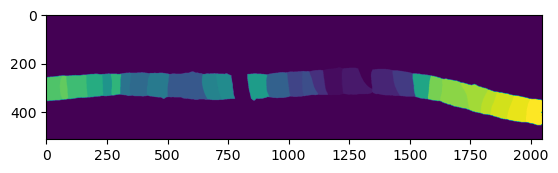

In [153]:
# check random input file

r = random.randint(0, len(names))
print(names[r])
print(imgs[r].shape)
plt.imshow(imgs[r])

In [145]:
# process images
cleaned_imgs = []
for image in imgs:
    processed = process_labels(image)
    cleaned_imgs.append(processed)

In [149]:
# save results
folder_out = 'cleaned_masks'
mask_path = os.path.join(path, 'manual_masks', folder_out)

try:
    os.mkdir(mask_path)
    print("Directory '% s' created" % folder_out)
except FileExistsError as error:
    print("Directory '% s' already exists" % folder_out)

print('Saving...')
for number, image in enumerate(cleaned_imgs):
    print(names[number])
    imwrite(os.path.join(mask_path, names[number]), image) 

Directory 'cleaned_masks' already exists


In [114]:
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
vals[0]=0.0
mymap = plt.cm.colors.ListedColormap(plt.cm.jet(vals))

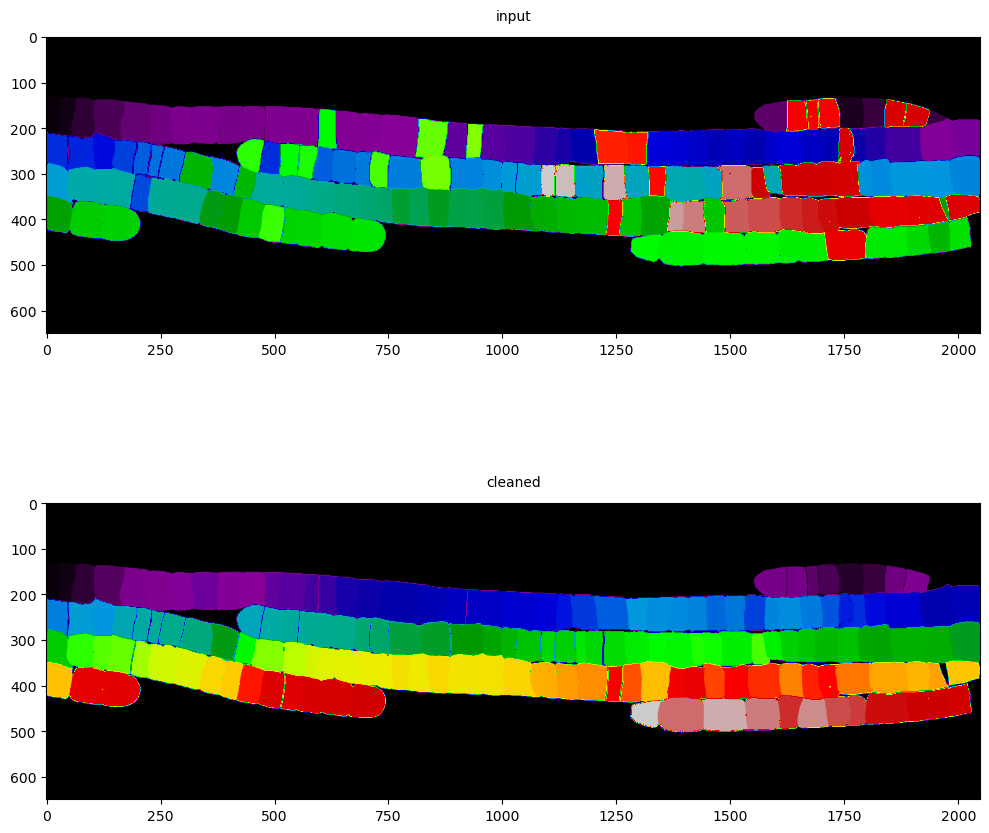

In [119]:
indice = 0
mycmap = 'nipy_spectral'
plt.figure(figsize=(10, 10))

plt.subplot((2),(1),(1))
plt.imshow(imgs[indice], cmap = mycmap)
plt.title('input', fontdict={'fontsize':10}, pad=12)

plt.subplot((2),(1),(2))
plt.imshow(cleaned_imgs[indice], cmap = mycmap)
plt.title('cleaned', fontdict={'fontsize':10}, pad=12)

plt.tight_layout()
plt.show()

Directory 'cleaned_masks' already exists
2022-01-05_CryoFM_NIBB-NO3_Lugoltest_labels masks_series_6.tif
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks\2022-01-05_CryoFM_NIBB-NO3_Lugoltest_labels masks_series_6.tif
2022-01-05_CryoFM_NIBB-NO3_Lugoltest_labels masks_series_7.tif
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks\2022-01-05_CryoFM_NIBB-NO3_Lugoltest_labels masks_series_7.tif
2022-12-06_CryoFM_IMS-N2_labels masks_series_2.tif
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks\2022-12-06_CryoFM_IMS-N2_labels masks_series_2.tif
2022-12-06_CryoFM_IMS-N2_labels masks_series_1.tif
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks
C:/Users/zuzka/Desktop/rasy/manual_masks\cleaned_masks\2022-12-06_CryoFM_IMS-N2_labels masks_series_1.tif
2022-12-06_CryoFM_IMS-NO3_labels masks_series_0.tif
C:/Users/zu

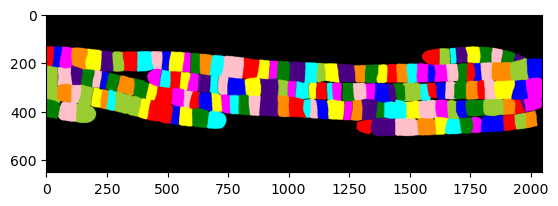

In [32]:
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
vals[0]=0.0
mycmap = plt.cm.colors.ListedColormap(plt.cm.jet(vals))

all_labels = measure.label(imgs[0])
blobs_labels = measure.label(imgs[0], background=0)

plt.imshow(color.label2rgb(blobs_labels, bg_label=0))

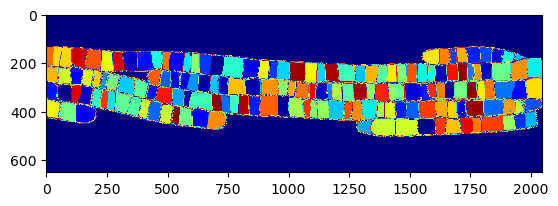

In [33]:
len(np.unique(blobs_labels))
len(np.unique(imgs[0]))
plt.imshow(blobs_labels, cmap=mycmap)

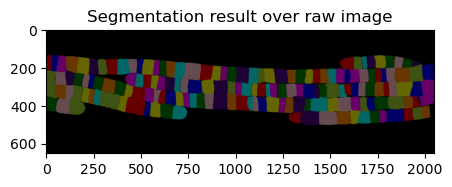

In [35]:
color_labels = color.label2rgb(blobs_labels, imgs[0], alpha=0.4, bg_label=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(color_labels)
ax.set_title('Segmentation result over raw image')
plt.show()

In [62]:
# define functions
props = measure.regionprops(blobs_labels)
for region in measure.regionprops(blobs_labels):
    # take regions with large enough areas
    if region.area <= 50:
        print(region.area)
    print(np.max(region.area))


2432
2561
3603
3891
3004
2802
5012
1552
2491
2839
3892
2
2
5141
1
1
2267
4055
1
1
4977
3022
3608
4537
2314
4643
2369
3132
800
3852
4250
7262
5749
4948
4828
3465
2396
3953
5184
5846
4099
3151
2563
2232
1976
4060
3523
2668
5002
3350
3161
3239
3280
2922
2037
2948
3505
3878
3284
2981
2
2
3775
2
2
1
1
1
1
1
1
3218
3107
1
1
1
1
2811
2244
1
1
2779
1646
2522
2849
3214
3575
4507
2307
2911
2
2
1
1
4943
4578
5337
3899
4785
10
10
1
1
3365
2506
2213
4368
5738
2108
3594
1
1
3573
3549
2688
3374
2988
2521
1976
2706
3499
7
7
1
1
1535
3600
4873
2116
4333
2423
2348
2723
1933
4107
2166
2698
3807
4339
1
1
2891
3491
2
2
5
5
2160
2627
1949
4721
2409
3769
2862
2624
3531
6322
4033
2789
3640
3637
4891
4
4
3085
3280
3955
5079
3020
2001
2151
5427
1800
3427
5198
3507
4894
464
3494
3204
5086
2834
3944
2775
3778
2410
2007
2
2
1
1
3225
5251
5467
3762
2347
3995
1
1
4931
92
2881
4846
4
4
2853
3086
5995
3125
2269
3280
6956
5021
3735
6531
1
1
2964


In [75]:
data = measure.regionprops_table(
        blobs_labels,
        properties=('label', 'area'),
        )
table = pd.DataFrame(data)

area_threshold = 800
area_labels = table['label'] * (table['area'] > area_threshold)
new_labels = map_array(
        blobs_labels,
        np.asarray(table['label']),
        np.asarray(area_labels),
        )
new_labels=morphology.opening(new_labels)

162

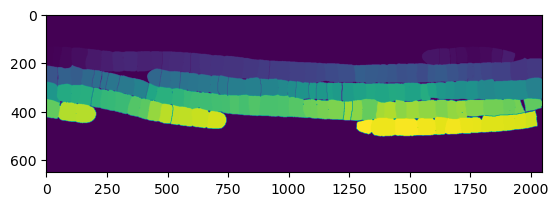

In [80]:
test = morphology.opening(new_labels)
plt.imshow(test)

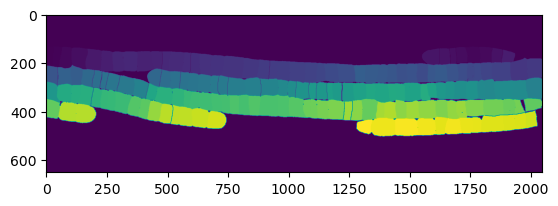

In [76]:
plt.imshow(new_labels)

In [38]:
path = "C:/Users/zuzka/Desktop/rasy/"
folder_composite = 'composites/'
folder_masks = "masks/"


files_img = [f for f in os.listdir(path + folder_composite) if f.endswith(".tif")]

imgs = [imread(path + folder_composite + filename) for filename in files_img]

print(files_img)

['composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_1.tif.tif', 'composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_2.tif.tif', 'composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_3.tif.tif', 'composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_4.tif.tif', 'composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_5.tif.tif', 'composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_6.tif.tif', 'composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_7.tif.tif', 'composite-2022-01-05_CryoFM_NIBB-NO3_Lugoltest.lif - 4ch_NIBB+NO3_8.tif.tif', 'composite-2022-12-06_CryoFM_IMS-N2.lif - 4ch_IMS-N2_1.tif.tif', 'composite-2022-12-06_CryoFM_IMS-N2.lif - 4ch_IMS-N2_10.tif.tif', 'composite-2022-12-06_CryoFM_IMS-N2.lif - 4ch_IMS-N2_11.tif.tif', 'composite-2022-12-06_CryoFM_IMS-N2.lif - 4ch_IMS-N2_9.tif.tif', 'composite-2022-12-06_CryoFM_IMS-N2.lif - 4ch_IMS-NO3_1.tif.tif', 'composite-2022-12-06_CryoFM_IMS-N2.lif

In [43]:
img = imgs[0]
print(img.shape)
img = img.transpose((1,2,0))
print(img.shape)


(3, 575, 2048)
(575, 2048, 3)


In [45]:
for idx in range(len(files_img)):
    imgs[idx] = imgs[idx].transpose((1,2,0))

<Figure size 2000x1000 with 0 Axes>

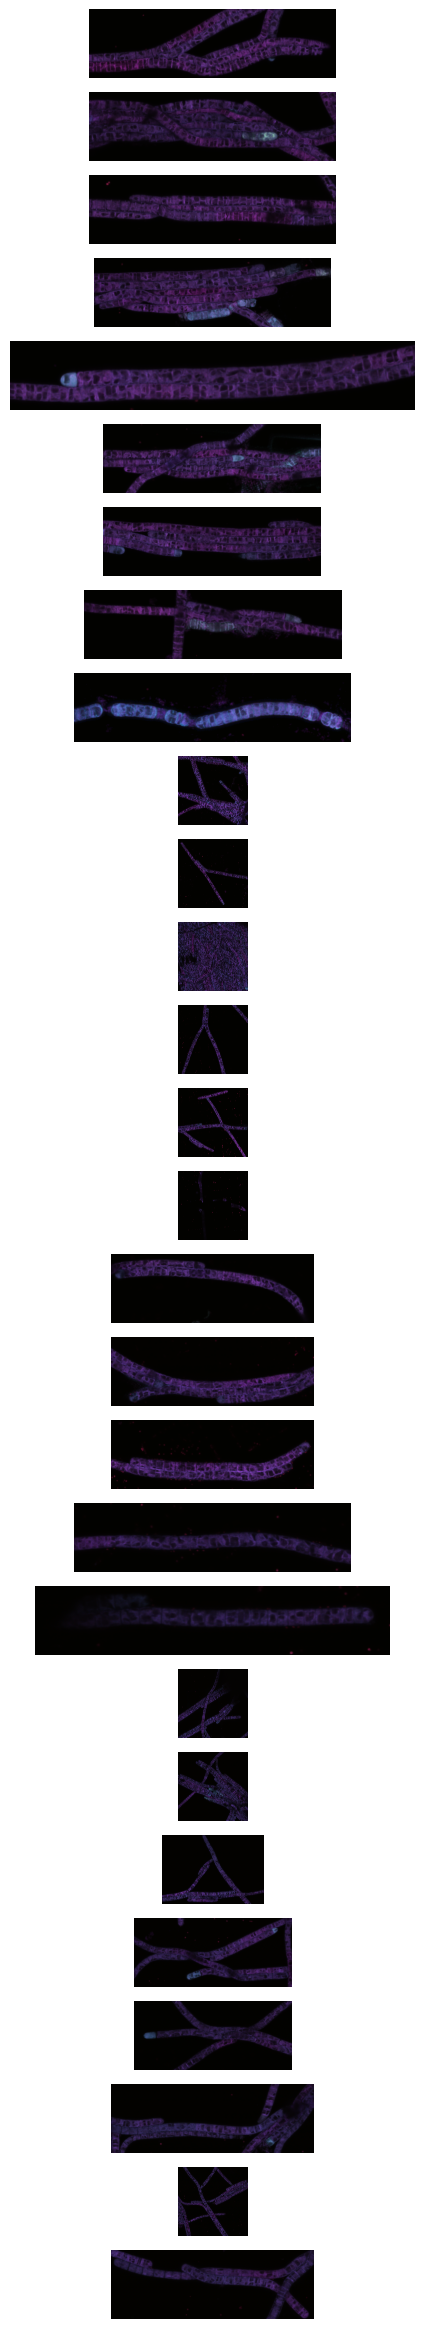

In [54]:
range_val = len(files_img)
plt.figure(figsize=(20,10))

fig, ax = plt.subplots(range_val,1, figsize=(20,30))

for number in range(range_val):
    ax[number].imshow(imgs[number])
    ax[number].axis("off")

In [55]:
# DEFINE CELLPOSE MODEL
# model_type='cyto' or model_type='nuclei'
model = models.CellposeModel(gpu=False, model_type='CP_20230221_test')

channels = [0,0]

# if diameter is set to None, the size of the cells is estimated on a per image basis
# you can set the average cell `diameter` in pixels yourself (recommended) 
# diameter can be a list or a single number for all images

# you can run all in a list e.g.
cells_masks, flows, styles = model.eval(imgs, diameter=125, channels=channels, flow_threshold = 0.99) #nuclei
#masks, flows, styles, diams = model.eval(imgsx, diameter=220, channels=channels)

#io.masks_flows_to_seg(imgs_nuc, nuc_masks, flows, files_nuc, channels)
# >>> io.save_to_png(imgs, masks, flows, files)

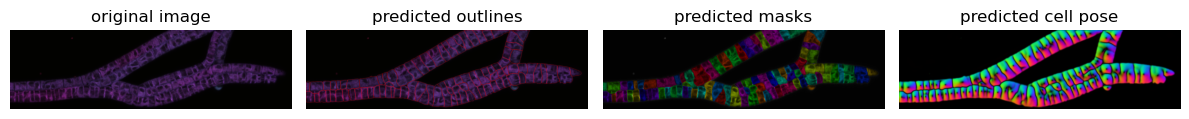

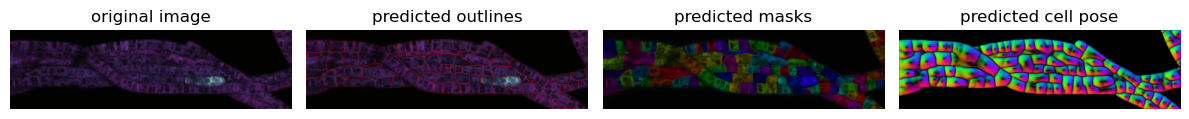

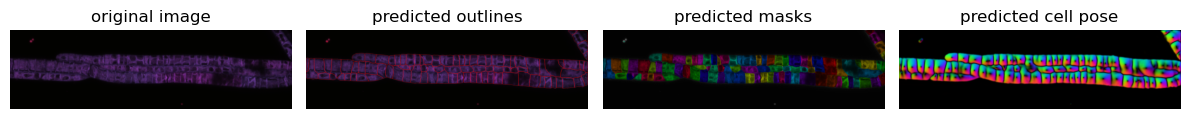

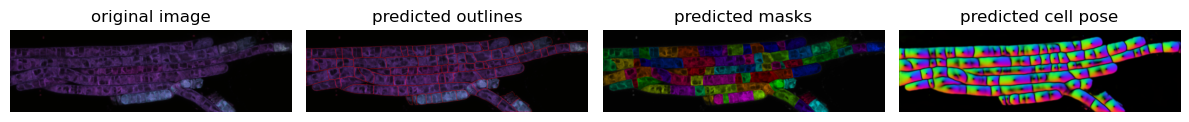

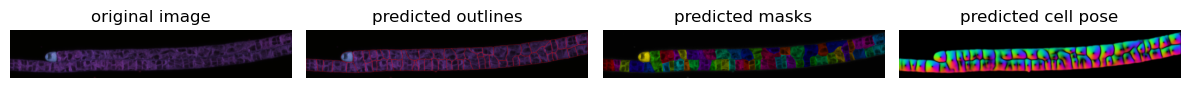

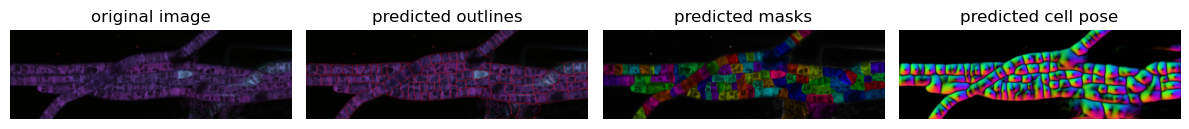

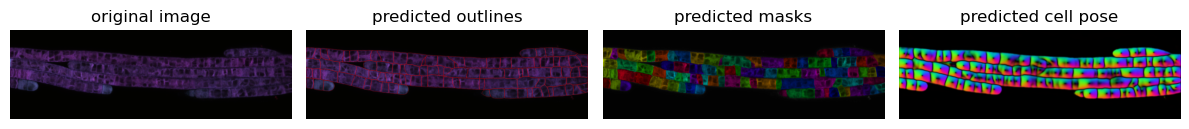

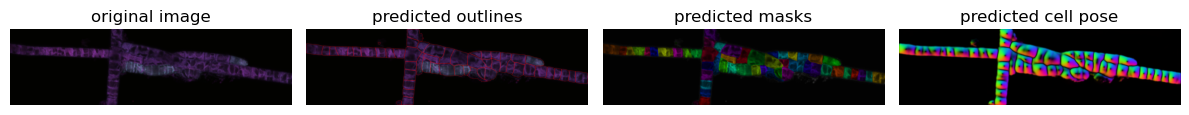

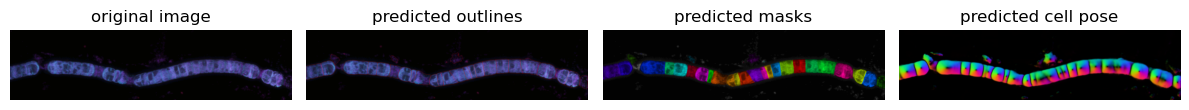

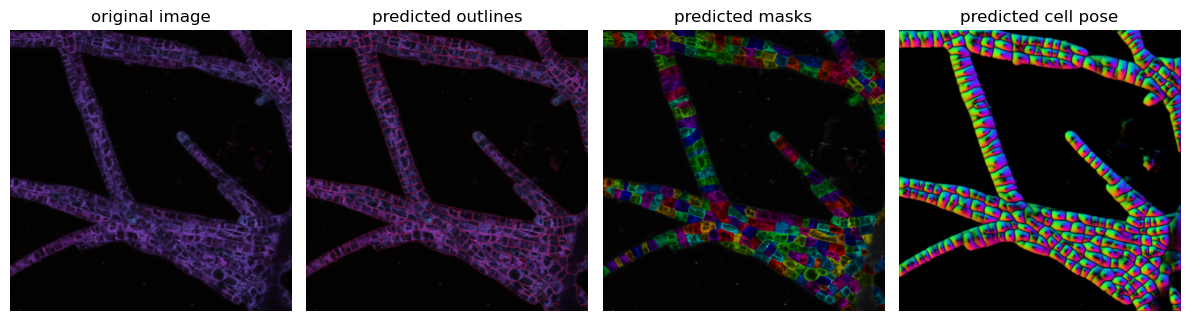

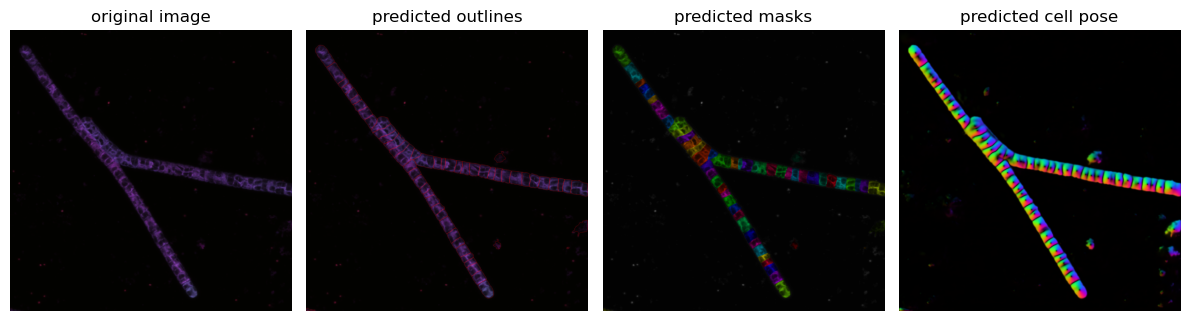

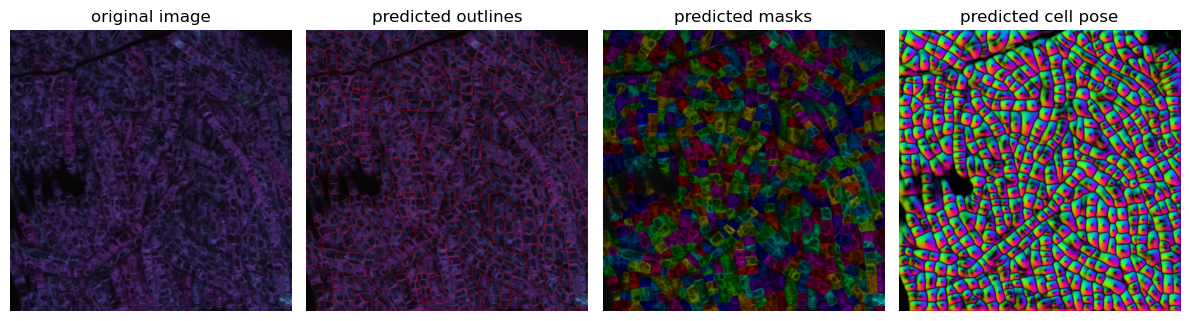

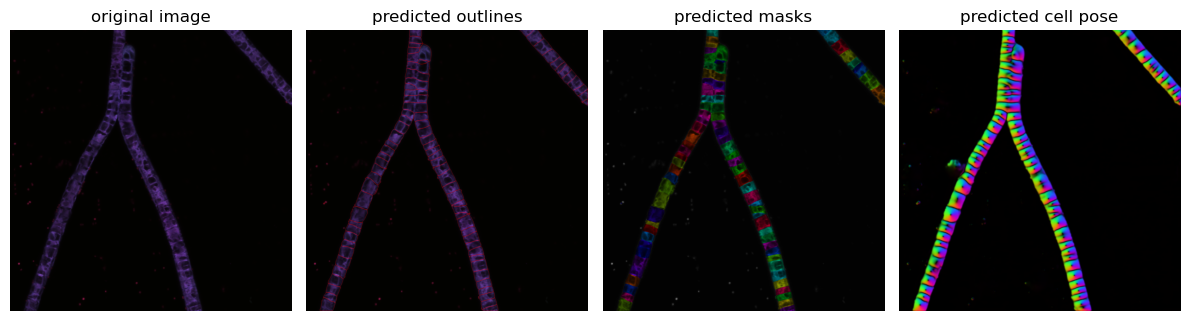

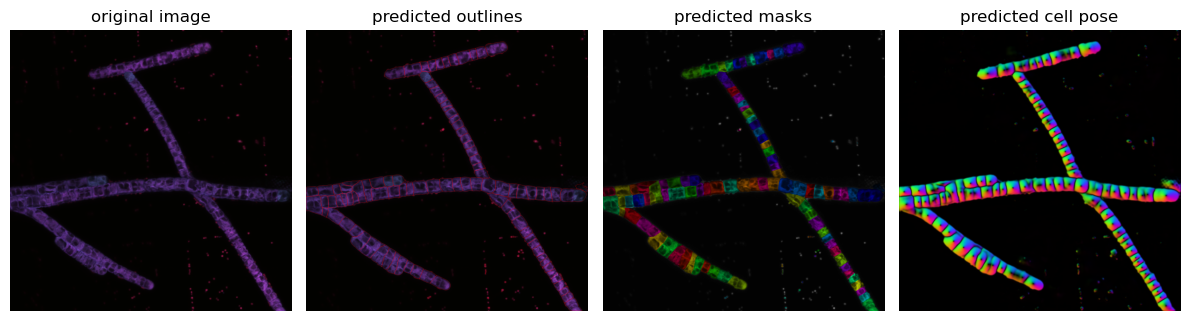

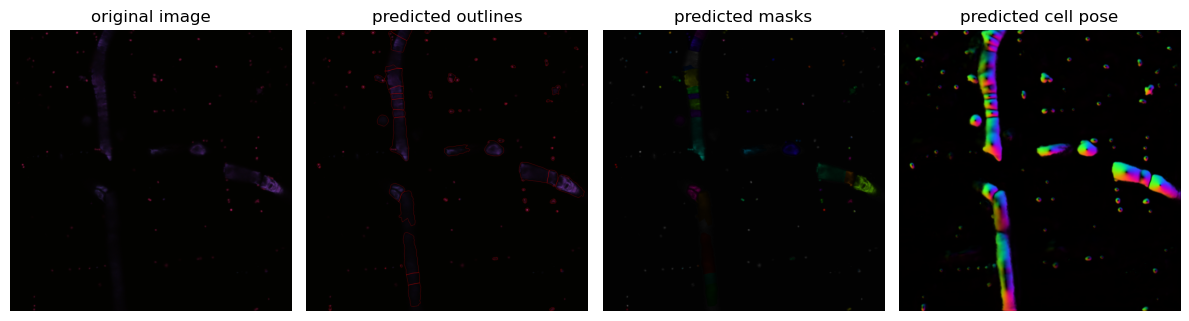

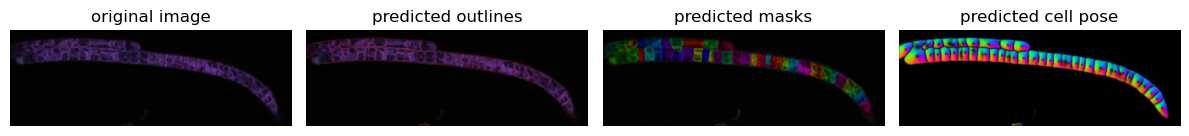

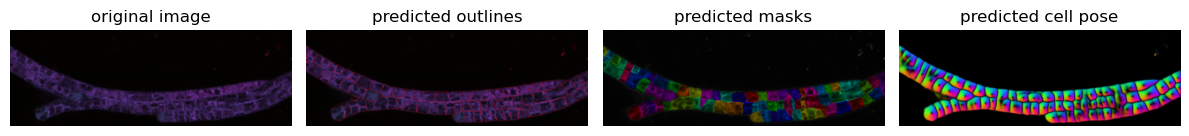

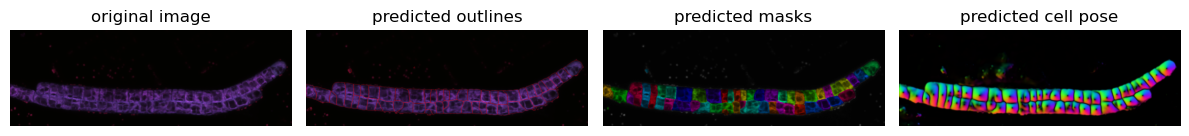

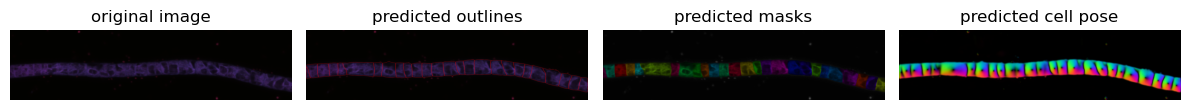

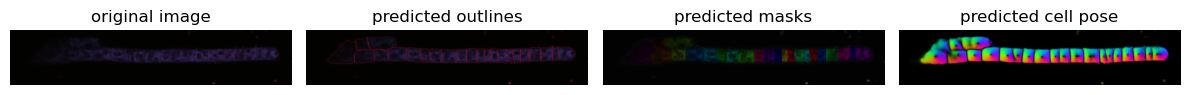

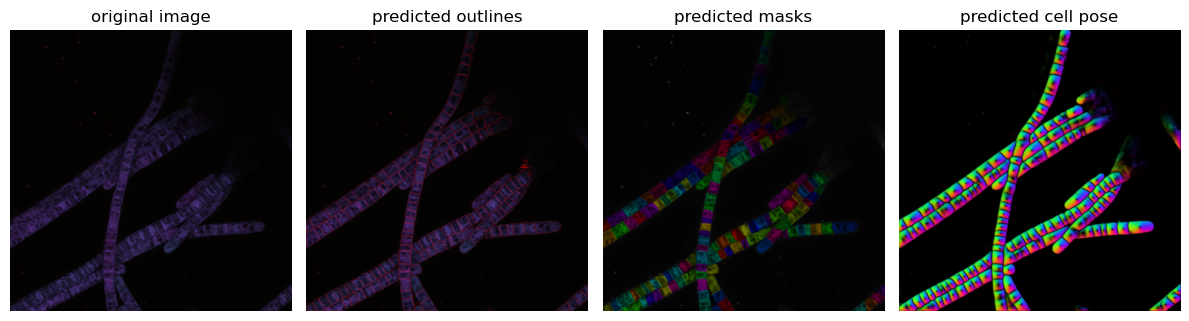

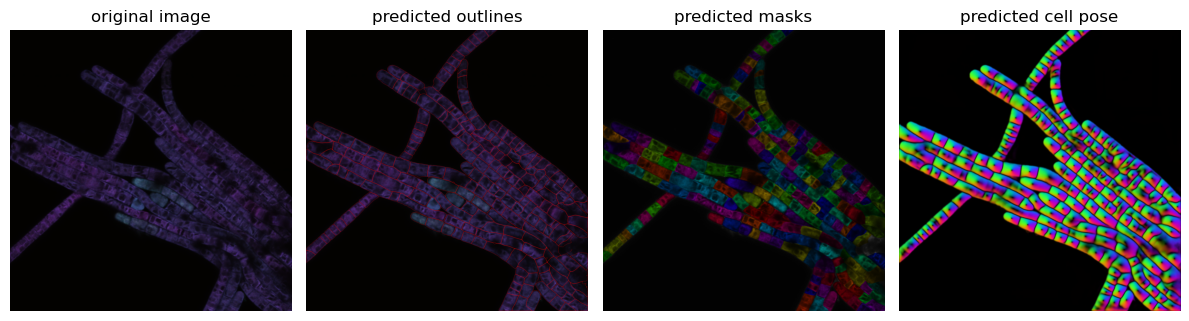

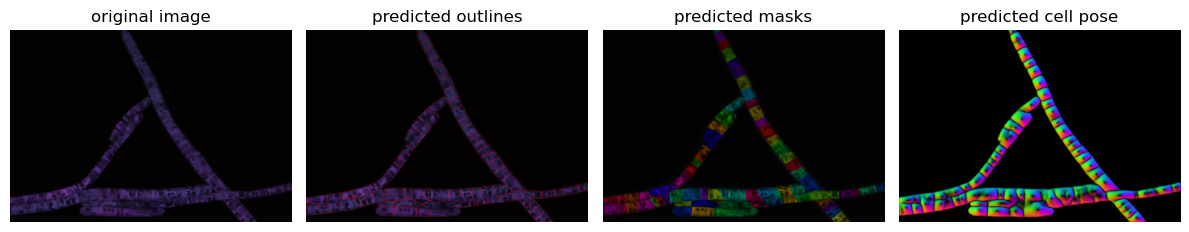

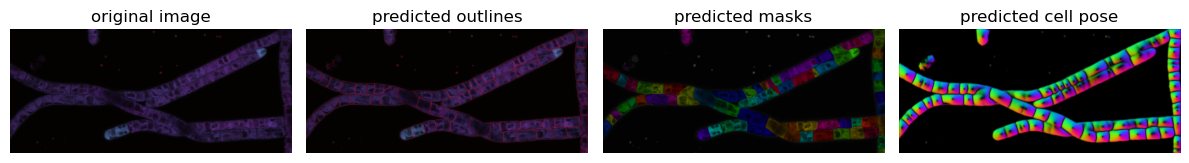

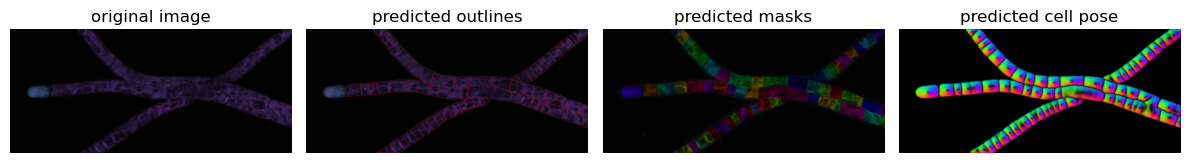

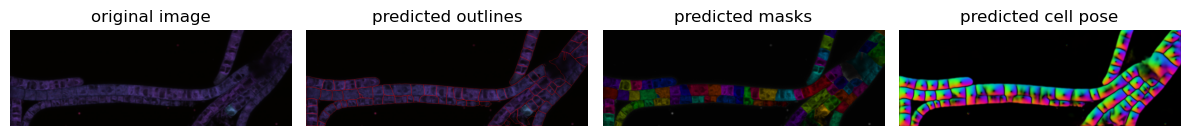

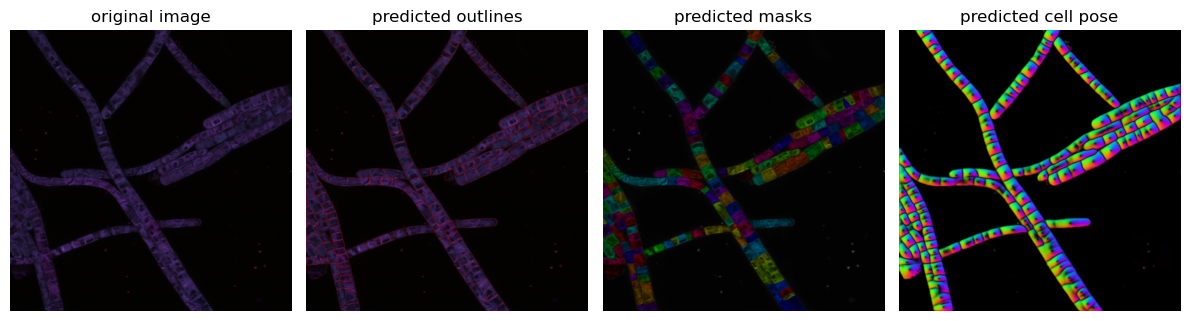

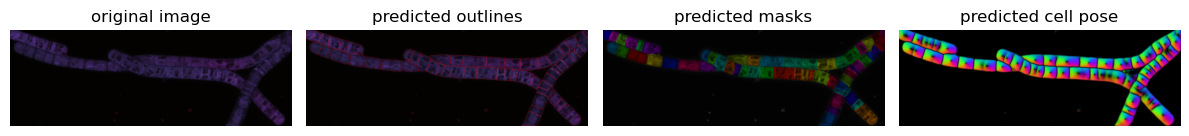

In [57]:
# DISPLAY RESULTS
from cellpose import plot


for i in range(len(files_img)):
    fig = plt.figure(figsize=(12,5))
    plot.show_segmentation(fig, imgs[i], cells_masks[i], flows[i][0], channels=channels)
    plt.tight_layout()
    plt.show()

In [71]:
outlines = []
for i in range(len(files_img)):
    outline = utils.outlines_list(cells_masks[i])
    outlines.append(outline)

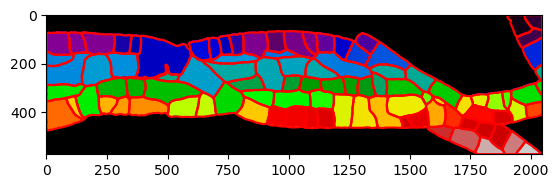

In [82]:
x = 1
plt.imshow(imgs[x])
for o in outlines[x]:
    plt.plot(o[:,0], o[:,1], color='r')
plt.imshow(cells_masks[x], cmap = "nipy_spectral")

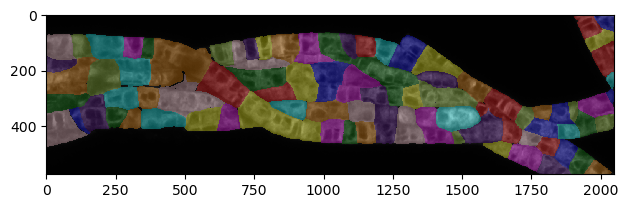

In [88]:
from skimage import io
from skimage import color

# Generate automatic colouring from classification labels
io.imshow(color.label2rgb(cells_masks[x],imgs[x]))
plt.show()

ValueError: `image` and `label` must be the same shape

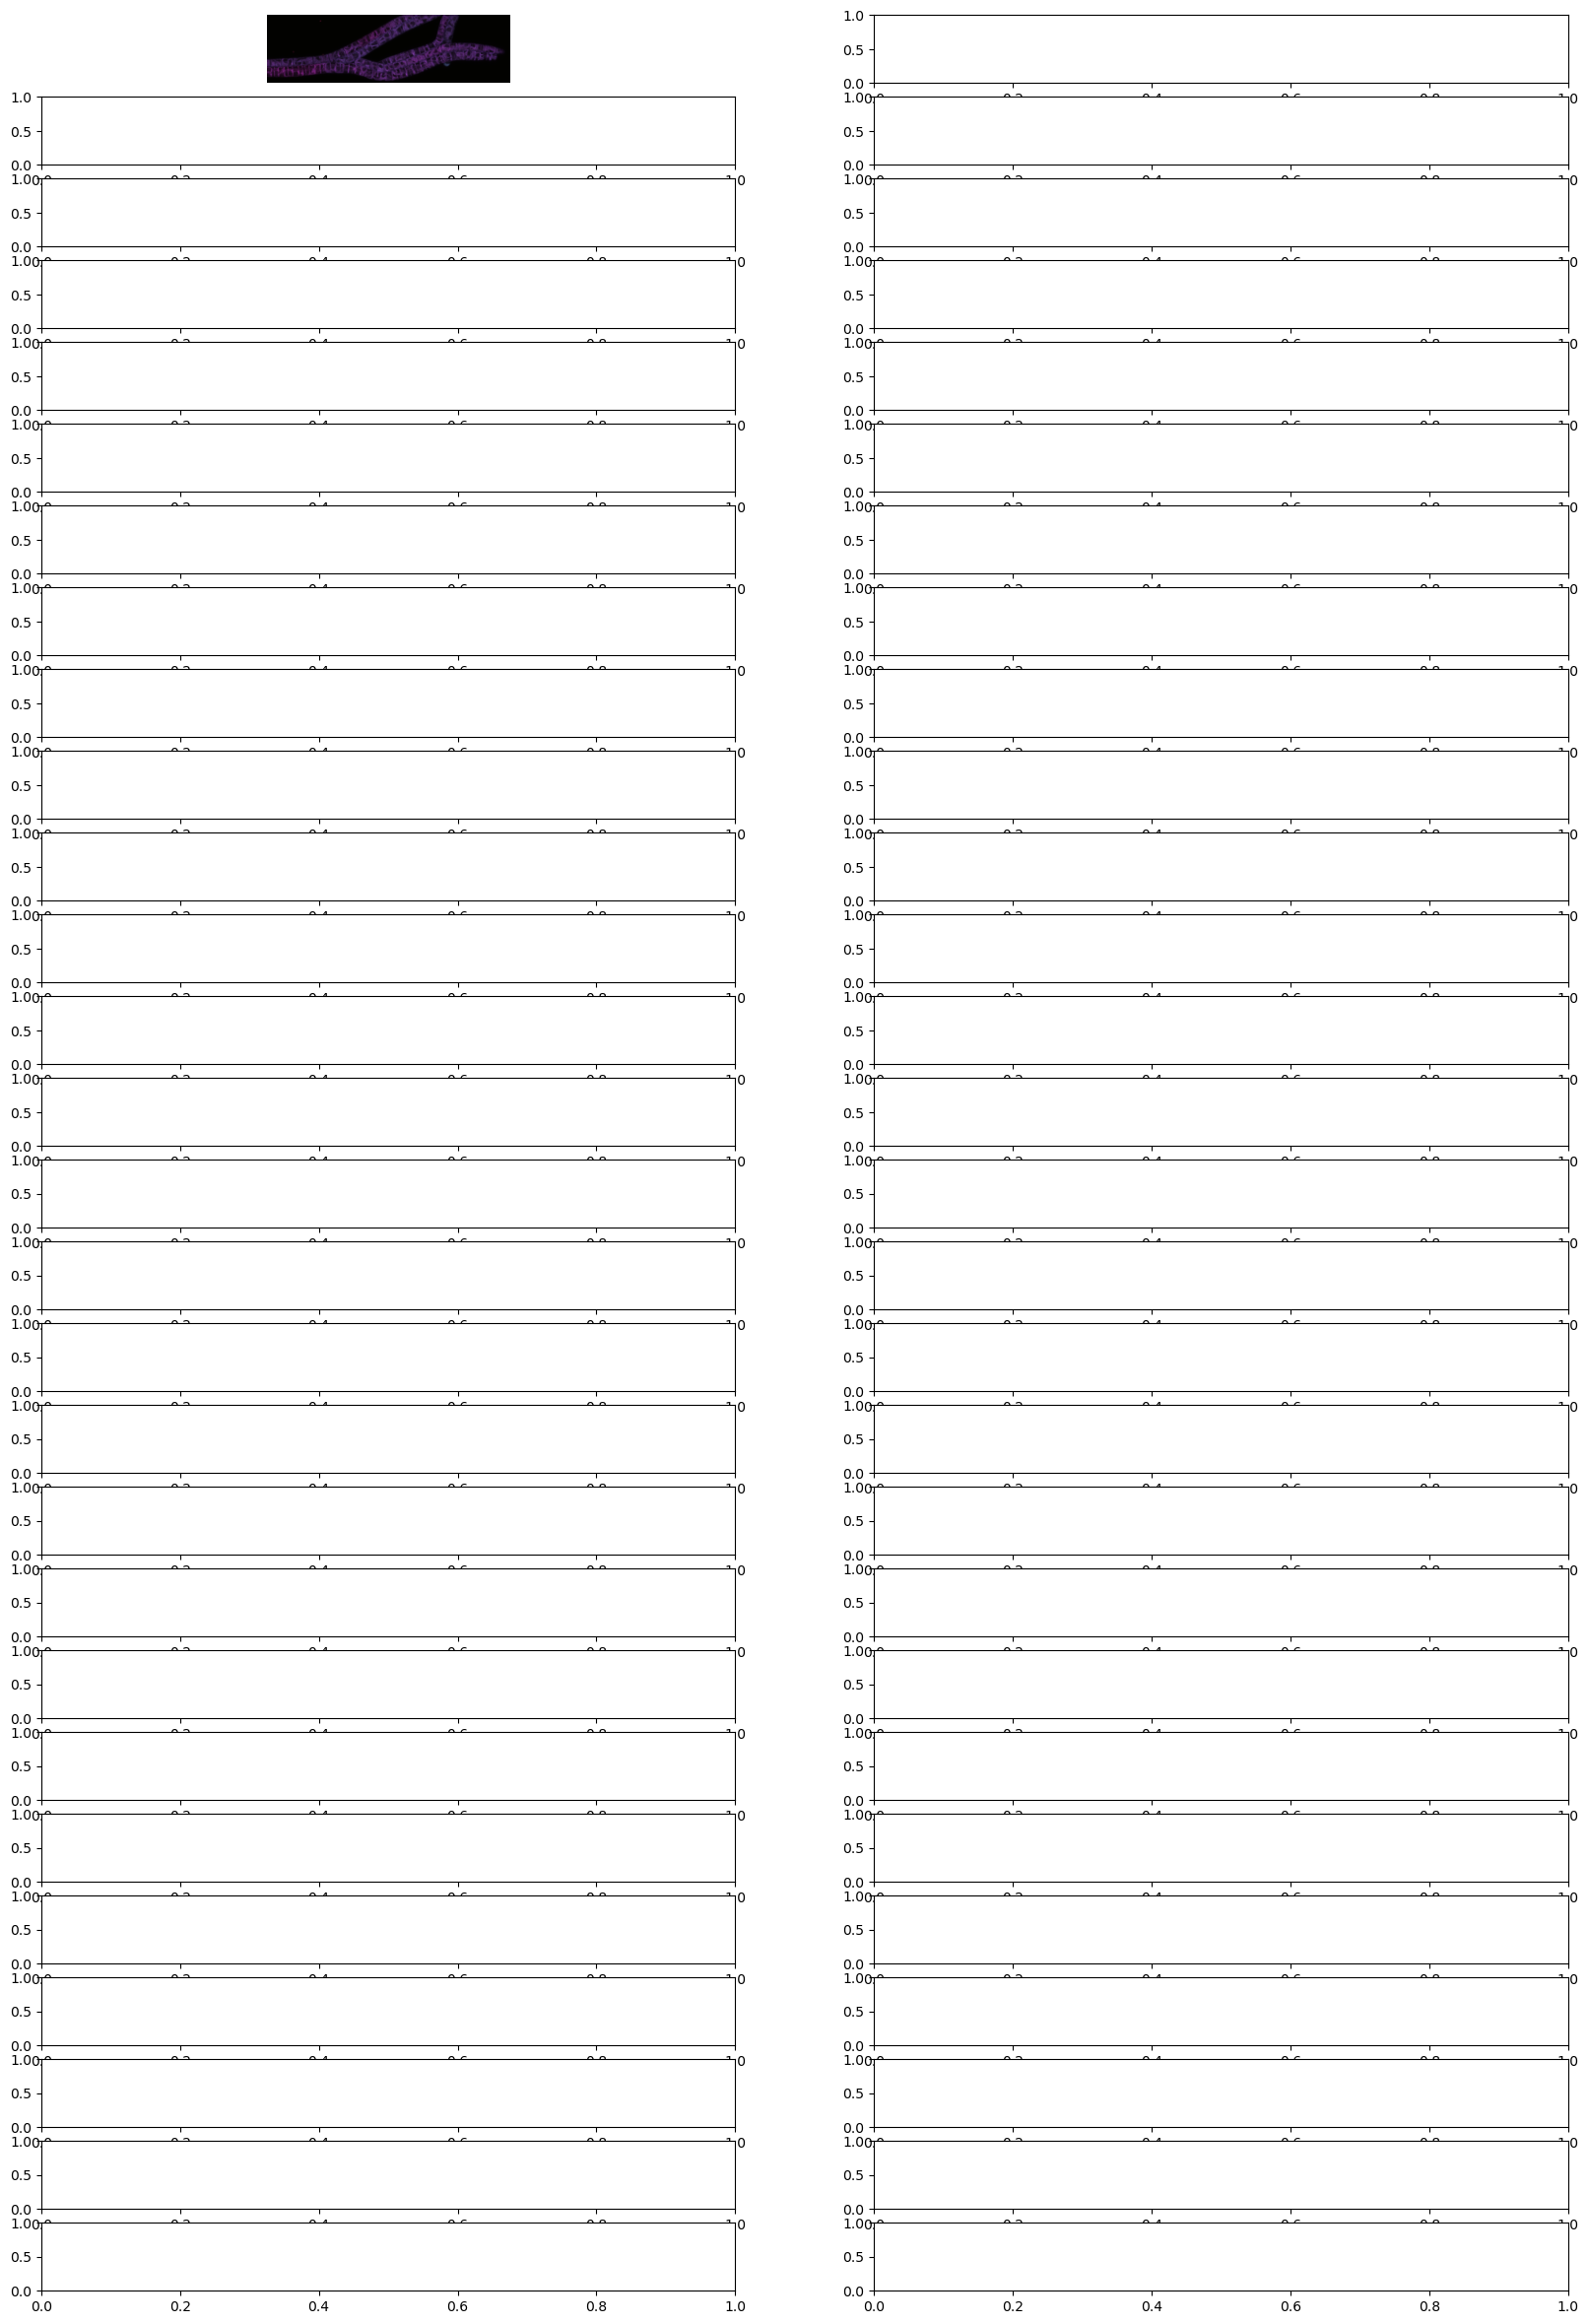

In [96]:
# view all images
folder_output = 'C:/Users/zuzka/Desktop/rasy/'

from matplotlib import colors
range_val = 2
n_groups = len(files_img)

fig, ax = plt.subplots(n_groups, range_val, figsize=(20,30))

for group in range(n_groups):
    im_list = []
    val = group
    im_list.extend([imgs[val], outlines[val], cells_masks[val]])
        
    for number in range(range_val):
        if number == 0:
            ax[group, number].imshow(im_list[number])
            ax[group, number].axis('off')

        else:
            ax[group, number].imshow(color.label2rgb(im_list[0][group],im_list[2][group]))
plt.savefig(folder_output+'QC.pdf')